In [1]:
import torch

In [2]:
import kagglehub

path = kagglehub.dataset_download("jacksoncrow/stock-market-dataset")


/home/rayyansiddiqui23/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print("Path to dataset files:", path)

Path to dataset files: /home/rayyansiddiqui23/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2


In [4]:
import os

print(os.listdir(path))
print(len(os.listdir(path)))

['etfs', 'stocks', 'symbols_valid_meta.csv']
3


In [5]:
path

'/home/rayyansiddiqui23/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2'

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [7]:
import pandas as pd

file_path = path + "/stocks/AAPL.csv"   # change filename based on output above
df = pd.read_csv(file_path)
df = df.sort_values('Date')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


In [64]:
data = df[['Close']].values

In [65]:
split = int(0.8 * len(data))

train_data = data[:split]
test_data = data[split:]

In [82]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [83]:
import numpy as np
def create_sequences(data, seq_length=100):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled)
X_test, y_test = create_sequences(test_scaled)

In [84]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)

X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

In [85]:
import torch.nn as nn

In [86]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=128,
            num_layers=2,
            dropout=0.2,
            batch_first=True
        )
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

In [87]:
model = LSTMModel().to(device)

In [88]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 500
for epoch in range(epochs):
    model.train()
    
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch+1}, Loss: {loss.item():.6f}")

Epoch 1, Loss: 0.044102
Epoch 2, Loss: 0.033111
Epoch 3, Loss: 0.026105
Epoch 4, Loss: 0.023379
Epoch 5, Loss: 0.024871
Epoch 6, Loss: 0.026716
Epoch 7, Loss: 0.026134
Epoch 8, Loss: 0.024473
Epoch 9, Loss: 0.022896
Epoch 10, Loss: 0.021995
Epoch 11, Loss: 0.021694
Epoch 12, Loss: 0.021699
Epoch 13, Loss: 0.021782
Epoch 14, Loss: 0.021680
Epoch 15, Loss: 0.021401
Epoch 16, Loss: 0.020886
Epoch 17, Loss: 0.020109
Epoch 18, Loss: 0.019185
Epoch 19, Loss: 0.018203
Epoch 20, Loss: 0.017192
Epoch 21, Loss: 0.016277
Epoch 22, Loss: 0.015345
Epoch 23, Loss: 0.014066
Epoch 24, Loss: 0.012149
Epoch 25, Loss: 0.009204
Epoch 26, Loss: 0.005358
Epoch 27, Loss: 0.003386
Epoch 28, Loss: 0.002602
Epoch 29, Loss: 0.004118
Epoch 30, Loss: 0.004693
Epoch 31, Loss: 0.003363
Epoch 32, Loss: 0.002094
Epoch 33, Loss: 0.001178
Epoch 34, Loss: 0.000733
Epoch 35, Loss: 0.000918
Epoch 36, Loss: 0.001228
Epoch 37, Loss: 0.001383
Epoch 38, Loss: 0.001376
Epoch 39, Loss: 0.001131
Epoch 40, Loss: 0.000746
Epoch 41,

In [89]:
model.eval()

with torch.no_grad():
    predictions = model(X_test).cpu().numpy()
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.cpu().numpy())

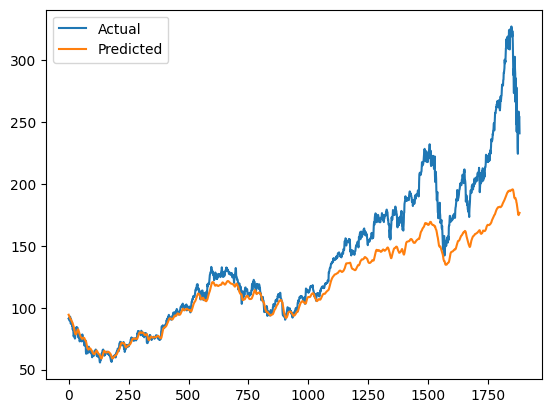

In [90]:
import matplotlib.pyplot as plt

plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.show()

In [91]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae = mean_absolute_error(y_test_actual, predictions)

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

RMSE: 31.63612937927246
MAE: 19.032711029052734


In [92]:
print("Pred sample:", predictions[:5])
print("Actual sample:", y_test_actual[:5])

Pred sample: [[94.36144]
 [93.85527]
 [93.27608]
 [92.74918]
 [92.16197]]
Actual sample: [[91.16714]
 [90.83571]
 [91.55857]
 [89.72857]
 [89.95857]]
